## 1. Setup

In [15]:
# 0. Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [16]:
# 1. Load
DATASET = "credit_card"
MESSY_DIR = f"../data/messy/{DATASET}"
CONDITIONS = ["clean", "missing_mild", "missing_severe",
              "outlier_mild", "outlier_severe", "noise_mild", "noise_severe"]

dfs = {}
for c in CONDITIONS:
    path = f"{MESSY_DIR}/{c}/train.csv"
    dfs[c] = pd.read_csv(path)
test_df = pd.read_csv(f"../data/processed/{DATASET}/test.csv")

for c, d in dfs.items():
    print(f"{c:<16} shape={d.shape}  missing={d.isnull().mean().mean():.2%}  pos_rate={d['default.payment.next.month'].mean():.3f}")
print(f"{'test':<16} shape={test_df.shape}")

clean            shape=(24000, 25)  missing=0.00%  pos_rate=0.221
missing_mild     shape=(24000, 25)  missing=9.60%  pos_rate=0.221
missing_severe   shape=(24000, 25)  missing=19.20%  pos_rate=0.221
outlier_mild     shape=(24000, 25)  missing=0.00%  pos_rate=0.221
outlier_severe   shape=(24000, 25)  missing=0.00%  pos_rate=0.221
noise_mild       shape=(24000, 25)  missing=0.00%  pos_rate=0.249
noise_severe     shape=(24000, 25)  missing=0.00%  pos_rate=0.335
test             shape=(6000, 25)


## 2. EDA

Following the protocol:
1. Basic data loading check (shape, info, columns, describe)
2. Basic descriptive stats (mean, median, std, skew)
3. Missing value profile (% and pattern)
4. Outlier profile (distribution shape, IQR count)
5. Class balance profile (check class balance)
6. Correlation matrix

In [17]:
# 1. Basic data loading (all conditions + test)
all_dfs = dfs.copy()
all_dfs["test"] = test_df

for name, d in all_dfs.items():
    print(f"\n{'='*70}\n  {name.upper()}\n{'='*70}")
    print(f"Data Shape: {d.shape}")
    print("\nData Info:")
    d.info()
    print("\nData Columns:")
    print(d.columns.tolist())
    print("\nData Description:")
    display(d.describe())


  CLEAN
Data Shape: (24000, 25)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          24000 non-null  int64  
 1   LIMIT_BAL                   24000 non-null  float64
 2   SEX                         24000 non-null  int64  
 3   EDUCATION                   24000 non-null  int64  
 4   MARRIAGE                    24000 non-null  int64  
 5   AGE                         24000 non-null  int64  
 6   PAY_0                       24000 non-null  int64  
 7   PAY_2                       24000 non-null  int64  
 8   PAY_3                       24000 non-null  int64  
 9   PAY_4                       24000 non-null  int64  
 10  PAY_5                       24000 non-null  int64  
 11  PAY_6                       24000 non-null  int64  
 12  BILL_AMT1                   24000 non-null 

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,14973.683417,167364.666667,1.604750,1.853792,1.552875,35.432625,-0.014125,-0.134083,-0.166917,-0.221333,...,43156.661458,40164.412625,38675.979875,5623.556292,5.879975e+03,5215.777583,4790.331833,4769.941750,5229.905500,0.221208
std,8641.664947,129511.313151,0.488915,0.792375,0.521903,9.195256,1.123155,1.198818,1.194166,1.161924,...,64046.730878,60627.850612,59308.737828,16148.316646,2.025298e+04,17513.554475,15060.693585,15048.470405,17850.346975,0.415069
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7513.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2332.000000,1746.000000,1225.000000,1000.000000,8.400000e+02,390.000000,291.000000,246.000000,100.000000,0.000000
50%,14966.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19004.500000,18102.500000,16993.000000,2100.500000,2.014000e+03,1805.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,22438.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54386.500000,50142.250000,48977.250000,5018.250000,5.000000e+03,4580.500000,4015.250000,4040.000000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000



  MISSING_MILD
Data Shape: (24000, 25)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          21600 non-null  float64
 1   LIMIT_BAL                   21600 non-null  float64
 2   SEX                         21600 non-null  float64
 3   EDUCATION                   21600 non-null  float64
 4   MARRIAGE                    21600 non-null  float64
 5   AGE                         21600 non-null  float64
 6   PAY_0                       21600 non-null  float64
 7   PAY_2                       21600 non-null  float64
 8   PAY_3                       21600 non-null  float64
 9   PAY_4                       21600 non-null  float64
 10  PAY_5                       21600 non-null  float64
 11  PAY_6                       21600 non-null  float64
 12  BILL_AMT1                   21600 no

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.00000,21600.000000,21600.000000,...,21600.000000,21600.000000,21600.000000,21600.000000,2.160000e+04,21600.000000,21600.000000,21600.000000,21600.000000,24000.000000
mean,14983.288102,167757.500000,1.603889,1.851713,1.553241,35.414630,-0.017685,-0.13500,-0.166852,-0.220046,...,43235.284028,40232.736250,38797.411759,5612.673889,5.895543e+03,5190.716852,4829.574630,4802.287546,5162.921250,0.221208
std,8640.400642,129739.864768,0.489099,0.790062,0.521441,9.180053,1.119865,1.19675,1.193503,1.164651,...,64087.951097,60685.034439,59371.839381,15989.371248,2.061157e+04,17445.773501,15406.254946,15246.627091,17115.407371,0.415069
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.00000,-2.000000,-2.000000,...,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7545.500000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.00000,-1.000000,-1.000000,...,2319.750000,1722.750000,1204.500000,1000.000000,8.270000e+02,390.000000,281.750000,247.000000,100.000000,0.000000
50%,14987.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.00000,0.000000,0.000000,...,19036.500000,18066.000000,17021.000000,2106.000000,2.015000e+03,1803.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,22429.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.00000,0.000000,0.000000,...,54661.250000,50298.000000,49235.750000,5024.000000,5.000000e+03,4600.000000,4044.250000,4100.000000,4000.000000,0.000000
max,29999.000000,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.00000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000



  MISSING_SEVERE
Data Shape: (24000, 25)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          19200 non-null  float64
 1   LIMIT_BAL                   19200 non-null  float64
 2   SEX                         19200 non-null  float64
 3   EDUCATION                   19200 non-null  float64
 4   MARRIAGE                    19200 non-null  float64
 5   AGE                         19200 non-null  float64
 6   PAY_0                       19200 non-null  float64
 7   PAY_2                       19200 non-null  float64
 8   PAY_3                       19200 non-null  float64
 9   PAY_4                       19200 non-null  float64
 10  PAY_5                       19200 non-null  float64
 11  PAY_6                       19200 non-null  float64
 12  BILL_AMT1                   19200 

...

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,14973.683417,167364.666667,1.604750,1.853792,1.552875,35.432625,-0.014125,-0.134083,-0.166917,-0.221333,...,43156.661458,40164.412625,38675.979875,5623.556292,5.879975e+03,5215.777583,4790.331833,4769.941750,5229.905500,0.248708
std,8641.664947,129511.313151,0.488915,0.792375,0.521903,9.195256,1.123155,1.198818,1.194166,1.161924,...,64046.730878,60627.850612,59308.737828,16148.316646,2.025298e+04,17513.554475,15060.693585,15048.470405,17850.346975,0.432273
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7513.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2332.000000,1746.000000,1225.000000,1000.000000,8.400000e+02,390.000000,291.000000,246.000000,100.000000,0.000000
50%,14966.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19004.500000,18102.500000,16993.000000,2100.500000,2.014000e+03,1805.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,22438.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54386.500000,50142.250000,48977.250000,5018.250000,5.000000e+03,4580.500000,4015.250000,4040.000000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000



  NOISE_SEVERE
Data Shape: (24000, 25)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          24000 non-null  int64  
 1   LIMIT_BAL                   24000 non-null  float64
 2   SEX                         24000 non-null  int64  
 3   EDUCATION                   24000 non-null  int64  
 4   MARRIAGE                    24000 non-null  int64  
 5   AGE                         24000 non-null  int64  
 6   PAY_0                       24000 non-null  int64  
 7   PAY_2                       24000 non-null  int64  
 8   PAY_3                       24000 non-null  int64  
 9   PAY_4                       24000 non-null  int64  
 10  PAY_5                       24000 non-null  int64  
 11  PAY_6                       24000 non-null  int64  
 12  BILL_AMT1                   24000 no

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,14973.683417,167364.666667,1.604750,1.853792,1.552875,35.432625,-0.014125,-0.134083,-0.166917,-0.221333,...,43156.661458,40164.412625,38675.979875,5623.556292,5.879975e+03,5215.777583,4790.331833,4769.941750,5229.905500,0.334542
std,8641.664947,129511.313151,0.488915,0.792375,0.521903,9.195256,1.123155,1.198818,1.194166,1.161924,...,64046.730878,60627.850612,59308.737828,16148.316646,2.025298e+04,17513.554475,15060.693585,15048.470405,17850.346975,0.471840
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-81334.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7513.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2332.000000,1746.000000,1225.000000,1000.000000,8.400000e+02,390.000000,291.000000,246.000000,100.000000,0.000000
50%,14966.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19004.500000,18102.500000,16993.000000,2100.500000,2.014000e+03,1805.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,22438.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54386.500000,50142.250000,48977.250000,5018.250000,5.000000e+03,4580.500000,4015.250000,4040.000000,4000.000000,1.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.215471e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000



  TEST
Data Shape: (6000, 25)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          6000 non-null   int64  
 1   LIMIT_BAL                   6000 non-null   float64
 2   SEX                         6000 non-null   int64  
 3   EDUCATION                   6000 non-null   int64  
 4   MARRIAGE                    6000 non-null   int64  
 5   AGE                         6000 non-null   int64  
 6   PAY_0                       6000 non-null   int64  
 7   PAY_2                       6000 non-null   int64  
 8   PAY_3                       6000 non-null   int64  
 9   PAY_4                       6000 non-null   int64  
 10  PAY_5                       6000 non-null   int64  
 11  PAY_6                       6000 non-null   int64  
 12  BILL_AMT1                   6000 non-null   flo

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,...,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,15107.766333,167962.946667,1.599667,1.850500,1.547833,35.697000,-0.027000,-0.132500,-0.163333,-0.218000,...,43688.099000,40899.354333,39654.882500,5823.677333,6.085918e+03,5265.297167,4969.057000,4917.171167,5157.890833,0.221167
std,8734.831845,130698.538357,0.490007,0.782252,0.522262,9.305713,1.126417,1.190734,1.207711,1.197657,...,65468.536253,61471.293451,60524.310508,18128.961193,3.184007e+04,17977.164797,17884.895787,16165.776457,17484.253835,0.415067
min,2.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-53007.000000,-150953.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7448.000000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2302.500000,1885.000000,1368.500000,934.750000,7.920000e+02,391.000000,300.000000,279.750000,189.000000,0.000000
50%,15115.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19201.500000,18144.500000,17339.500000,2100.000000,2.000000e+03,1800.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,22758.500000,240000.000000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,0.000000,...,54859.000000,50480.500000,49883.750000,5000.000000,5.000000e+03,4366.250000,4003.250000,4021.250000,4122.250000,0.000000
max,29997.000000,800000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,7.000000,8.000000,8.000000,...,706864.000000,514114.000000,499100.000000,493358.000000,1.684259e+06,417588.000000,528897.000000,379267.000000,443001.000000,1.000000


In [18]:
# 2. Basic descriptive stats (mean, median, std, skew)

# number columns only
num_cols = []
for col in all_dfs["clean"].select_dtypes(include="number").columns:
    if col != "default.payment.next.month" and col != "ID":
        num_cols.append(col)

d = all_dfs["clean"][num_cols]
stats = pd.DataFrame({
    "mean": d.mean(), "median": d.median(), "std": d.std(), "skew": d.skew()
}).round(3)

print(stats.to_string())

                 mean    median         std    skew
LIMIT_BAL  167364.667  140000.0  129511.313   1.000
SEX             1.605       2.0       0.489  -0.429
EDUCATION       1.854       2.0       0.792   0.992
MARRIAGE        1.553       2.0       0.522  -0.029
AGE            35.433      34.0       9.195   0.738
PAY_0          -0.014       0.0       1.123   0.744
PAY_2          -0.134       0.0       1.199   0.804
PAY_3          -0.167       0.0       1.194   0.826
PAY_4          -0.221       0.0       1.162   0.940
PAY_5          -0.270       0.0       1.125   0.938
PAY_6          -0.293       0.0       1.145   0.886
BILL_AMT1   51100.502   22330.0   73510.032   2.691
BILL_AMT2   49012.268   21107.0   70840.102   2.728
BILL_AMT3   46861.880   20031.0   68403.934   2.729
BILL_AMT4   43156.661   19004.5   64046.731   2.823
BILL_AMT5   40164.413   18102.5   60627.851   2.920
BILL_AMT6   38675.980   16993.0   59308.738   2.882
PAY_AMT1     5623.556    2100.5   16148.317  15.312
PAY_AMT2    

In [19]:
# 3. Missing value profile (% per column, all conditions)
missing_pct = pd.DataFrame(
    {name: d.isnull().mean() * 100 for name, d in all_dfs.items()}
).round(2)

print("Missing Value in % (per column, per condition):")
print(missing_pct.to_string())

print("\nOverall missing % per condition:")
print(missing_pct.mean().round(2).to_string())

Missing Value in % (per column, per condition):
                            clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe  test
ID                            0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
LIMIT_BAL                     0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
SEX                           0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
EDUCATION                     0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
MARRIAGE                      0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
AGE                           0.0          10.0            20.0           0.0             0.0         0.0           0.0   0.0
PAY_0                         0.0          10.0            20.0       

In [20]:
# 3b. Missing pattern
for name in ["missing_mild", "missing_severe"]:
    d = all_dfs[name]
    print(f"\n{name.upper()} - missing % by target class:")
    table = d.groupby("default.payment.next.month").apply(lambda g: g[num_cols].isnull().mean()*100)
    print(table.round(2).T.to_string())


MISSING_MILD - missing % by target class:
default.payment.next.month     0      1
LIMIT_BAL                   9.96  10.15
SEX                         9.96  10.15
EDUCATION                   9.96  10.15
MARRIAGE                    9.96  10.15
AGE                         9.96  10.15
PAY_0                       9.96  10.15
PAY_2                       9.96  10.15
PAY_3                       9.96  10.15
PAY_4                       9.96  10.15
PAY_5                       9.96  10.15
PAY_6                       9.96  10.15
BILL_AMT1                   9.96  10.15
BILL_AMT2                   9.96  10.15
BILL_AMT3                   9.96  10.15
BILL_AMT4                   9.96  10.15
BILL_AMT5                   9.96  10.15
BILL_AMT6                   9.96  10.15
PAY_AMT1                    9.96  10.15
PAY_AMT2                    9.96  10.15
PAY_AMT3                    9.96  10.15
PAY_AMT4                    9.96  10.15
PAY_AMT5                    9.96  10.15
PAY_AMT6                    9.96  10.

C:\Users\ARYA\AppData\Local\Temp\ipykernel_21588\2604917394.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = d.groupby("default.payment.next.month").apply(lambda g: g[num_cols].isnull().mean()*100)
C:\Users\ARYA\AppData\Local\Temp\ipykernel_21588\2604917394.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = d.groupby("default.payment.next.month").apply(lambda g: g[num_cols].isnull().mean()*100)


In [21]:
# 4. Outlier profile (distribution shape, IQR count)
def iqr_outlier_pct(d, cols):
    out = {}
    for c in cols:
        q1, q3 = d[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out[c] = ((d[c] < lo) | (d[c] > hi)).mean() * 100
    return pd.Series(out)

outlier_pct = pd.DataFrame(
    {name: iqr_outlier_pct(d, num_cols) for name, d in all_dfs.items()}
).round(2)

print("IQR outlier % (per column, per condition):")
print(outlier_pct.to_string())

skew = pd.DataFrame(
    {name: d[num_cols].skew() for name, d in all_dfs.items()}
).round(2)

print("\nSkewness (per column, per condition):")
print(skew.to_string())

IQR outlier % (per column, per condition):
           clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
LIMIT_BAL   0.57          0.52            0.45          5.26           11.71        0.57          0.57   0.52
SEX         0.00          0.00            0.00          0.00            0.00        0.00          0.00   0.00
EDUCATION   1.56          1.38            1.25          6.47           15.00        1.56          1.56   1.33
MARRIAGE    0.00          0.00            0.00          5.00           15.00        0.00          0.00   0.00
AGE         0.89          0.80            0.69          4.96            7.08        0.89          0.89   0.50
PAY_0      10.39          9.25            8.32          5.21           24.12       10.39         10.39  10.60
PAY_2      14.70         13.19           11.66         18.95           15.06       14.70         14.70  14.72
PAY_3      13.99         12.60           11.18         18.20           15.08 

In [22]:
# Ground-truth injection rate + range check
for cond in ["outlier_mild", "outlier_severe"]:
    d = all_dfs[cond]
    changed = (d[num_cols] != all_dfs["clean"][num_cols]).mean() * 100
    summary = pd.DataFrame({
        "changed_%": changed.round(2),
        "clean_min": all_dfs["clean"][num_cols].min(),
        "clean_max": all_dfs["clean"][num_cols].max(),
        f"{cond}_min": d[num_cols].min(),
        f"{cond}_max": d[num_cols].max(),
        "clean_std": all_dfs["clean"][num_cols].std().round(2),
        f"{cond}_std": d[num_cols].std().round(2),
    })
    print(f"\n{cond.upper()}")
    print(summary.to_string())


OUTLIER_MILD
           changed_%  clean_min  clean_max  outlier_mild_min  outlier_mild_max  clean_std  outlier_mild_std
LIMIT_BAL        5.0    10000.0  1000000.0    -350677.787966         1000000.0  129511.31         162222.34
SEX              5.0        1.0        2.0          1.000000               3.0       0.49              0.57
EDUCATION        5.0        0.0        6.0          0.000000               7.0       0.79              1.36
MARRIAGE         5.0        0.0        3.0          0.000000               4.0       0.52              0.74
AGE              5.0       21.0       75.0         -1.000000              75.0       9.20             11.54
PAY_0            5.0       -2.0        8.0         -2.000000               9.0       1.12              2.25
PAY_2            5.0       -2.0        8.0         -2.000000               9.0       1.20              2.31
PAY_3            5.0       -2.0        8.0         -2.000000               9.0       1.19              2.31
PAY_4         

In [23]:
# 5. Class balance profile (check class balance)
balance = pd.DataFrame(
    {name: d["default.payment.next.month"].value_counts(normalize=True).sort_index() * 100 for name, d in all_dfs.items()}
).round(2)

print("Class balance % (y=0 / y=1):")
print(balance.to_string())

Class balance % (y=0 / y=1):
                            clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
default.payment.next.month                                                                                                    
0                           77.88         77.88           77.88         77.88           77.88       75.13         66.55  77.88
1                           22.12         22.12           22.12         22.12           22.12       24.87         33.45  22.12


In [24]:
# 5b. Direct label noise check (ground truth vs clean)
clean_y = all_dfs["clean"]["default.payment.next.month"]

for cond in ["noise_mild", "noise_severe"]:
    noisy_y = all_dfs[cond]["default.payment.next.month"]
    flipped = noisy_y != clean_y
    print(f"\n{cond.upper()}")
    print(f"  Overall flip rate : {flipped.mean():.2%}")
    print(f"  Flipped 0 → 1     : {((clean_y == 0) & flipped).sum():,} "
          f"({flipped[clean_y == 0].mean():.2%} of class 0)")
    print(f"  Flipped 1 → 0     : {((clean_y == 1) & flipped).sum():,} "
          f"({flipped[clean_y == 1].mean():.2%} of class 1)")


NOISE_MILD
  Overall flip rate : 5.00%
  Flipped 0 → 1     : 930 (4.98% of class 0)
  Flipped 1 → 0     : 270 (5.09% of class 1)

NOISE_SEVERE
  Overall flip rate : 20.00%
  Flipped 0 → 1     : 3,760 (20.12% of class 0)
  Flipped 1 → 0     : 1,040 (19.59% of class 1)


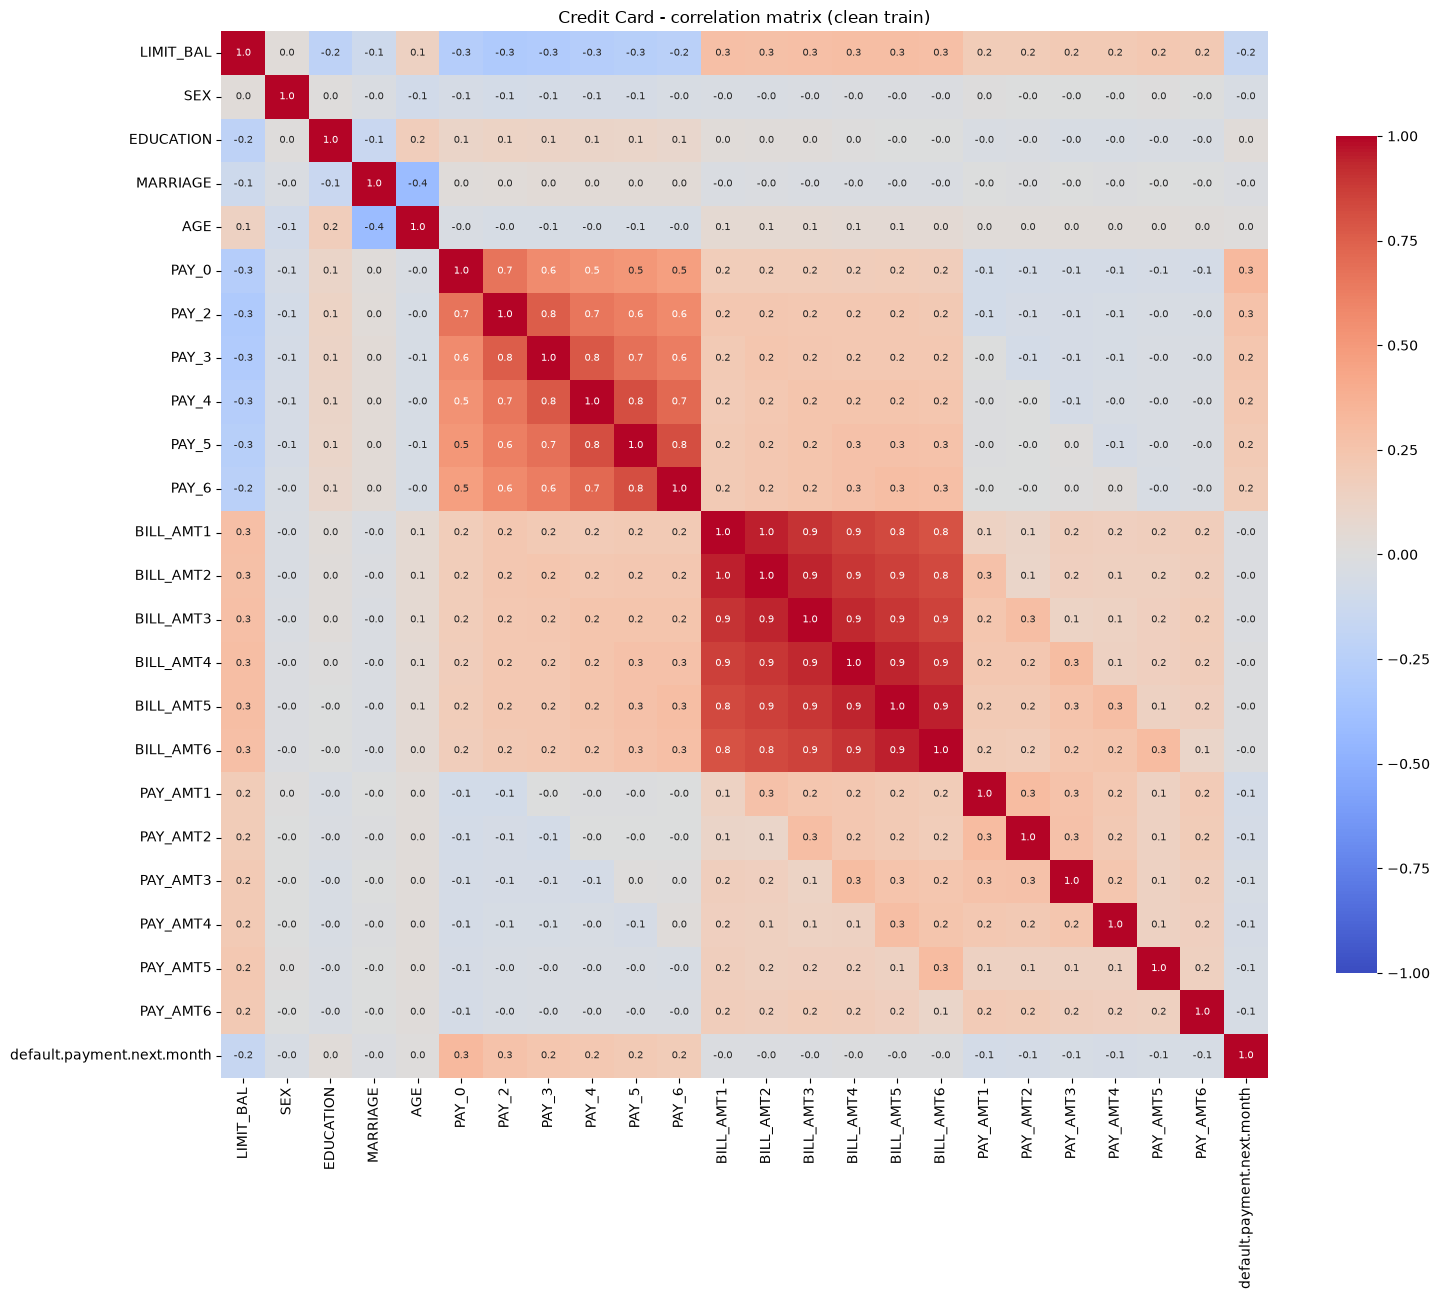

Correlation with y (per condition):
           clean  missing_mild  missing_severe  outlier_mild  outlier_severe  noise_mild  noise_severe   test
LIMIT_BAL -0.161        -0.161          -0.163        -0.116          -0.094      -0.146        -0.081 -0.124
SEX       -0.044        -0.044          -0.053        -0.037          -0.025      -0.038        -0.015 -0.024
EDUCATION  0.026         0.026           0.025         0.014           0.013       0.027         0.014  0.036
MARRIAGE  -0.020        -0.020          -0.018        -0.015          -0.005      -0.019        -0.006 -0.043
AGE        0.013         0.013           0.011         0.013           0.007       0.007         0.001  0.018
PAY_0      0.328         0.330           0.332         0.155           0.095       0.281         0.177  0.313
PAY_2      0.266         0.268           0.266         0.131           0.082       0.231         0.145  0.256
PAY_3      0.239         0.240           0.240         0.117           0.074       0

In [25]:
# 6. Correlation matrix
corr_cols = num_cols + ["default.payment.next.month"]

# 6a. Full heatmap - clean baseline
corr_clean = all_dfs["clean"][corr_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr_clean, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Credit Card - correlation matrix (clean train)")
plt.tight_layout()
plt.show()

# 6b. Correlation with target, per condition
target_corr = pd.DataFrame(
    {name: d[corr_cols].corr()["default.payment.next.month"].drop("default.payment.next.month") for name, d in all_dfs.items()}
).round(3)

print("Correlation with y (per condition):")
print(target_corr.to_string())

# 6c. How much each condition distorts the whole matrix vs clean
distortion = pd.Series(
    {name: (d[corr_cols].corr() - corr_clean).abs().values.mean() for name, d in all_dfs.items()}
).round(4)

print("\nMean absolute change in correlation vs clean:")
print(distortion.to_string())

In [26]:
print("ID missing %:", dfs["missing_severe"]["ID"].isnull().mean() * 100)
print("ID changed % (outliers):", (dfs["outlier_severe"]["ID"] != dfs["clean"]["ID"]).mean() * 100)

ID missing %: 20.0
ID changed % (outliers): 15.0
